## Business Question 1
## Branch Performance: Price vs. Volume Decomposition — Methodology

### What this analysis answers
Plain revenue tracking tells you *that* revenue changed, but not *why*.
This analysis decomposes month-over-month revenue change for each branch into
two independent drivers:

| Driver | Question answered |
|--------|------------------|
| **Volume Effect** | How much of the change is explained by selling *more (or fewer) units*? |
| **Price Effect**  | How much of the change is explained by charging a *higher (or lower) price per unit*? |

### Formulas
```
monthly_revenue  = SUM(price × quantity)    grouped by branch, month
monthly_qty      = SUM(quantity)             grouped by branch, month
avg_price        = monthly_revenue / monthly_qty

revenue_change   = current_revenue  − prior_revenue           (per branch, per month)
qty_change       = current_qty      − prior_qty
price_change     = current_avg_price − prior_avg_price

volume_effect    = qty_change   × prior_avg_price   ← qty moved at last month's price
price_effect     = price_change × current_qty       ← price delta on this month's volume
```
> **Note:** `volume_effect + price_effect ≈ revenue_change`.
> A small interaction term (`qty_change × price_change`) is omitted — it is negligible
> when changes are moderate and confounds interpretation.

### Interpretation guide
* **Price-led growth**: `price_effect > volume_effect` → value/mix improvement or pricing power.
* **Volume-led growth**: `volume_effect > price_effect` → footfall / transaction count driving growth.
* **Price-led decline**: negative `price_effect` despite stable volume → margin pressure.
* **Mixed signals**: effects point in opposite directions → investigate promotions or product mix.

### Data source
`qbs_smus_bronze.sales_raw` — transactional sales records.
Branch = `city` column (no explicit branch ID in the raw schema).

In [0]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np

raw = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")
print(raw.head())
print(raw.columns.tolist())
raw.columns = ['order_id', 
                'date', 
                'product',
                'price', 
                'quantity',
                'purchase_type',
                'payment_method',
                'manager',
                'city']

# ── Date parsing: try multiple formats, isolate unparseable rows ──────────────
def _parse_date(val):
    """Try DD-MM-YYYY (with / or - separator). Returns NaT on failure."""
    if pd.isna(val):
        return pd.NaT
    s = str(val).strip().replace('/', '-')
    for fmt in ('%d-%m-%Y', '%Y-%m-%d', '%m-%d-%Y', '%d-%m-%y', '%Y/%m/%d'):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

raw['date_parsed'] = raw['date'].apply(_parse_date)

# ── Separate invalid date rows into df_invalid ────────────────────────────────
df_invalid = raw[raw['date_parsed'].isna()].copy()
df_invalid = df_invalid.drop(columns=['date_parsed'])
print(f"\nInvalid / unparseable date rows : {len(df_invalid)}")
if not df_invalid.empty:
    print(df_invalid[['order_id', 'date']].to_string(index=False))

# ── Keep only valid rows and replace date column ──────────────────────────────
raw = raw[raw['date_parsed'].notna()].copy()
raw['date'] = raw['date_parsed']
raw = raw.drop(columns=['date_parsed'])

# ── Re-use the already-cleaned _df from the prep cell ───────────────────────
# _df has: date (datetime), city (branch), price (float), quantity (float)
# city is used as the branch dimension throughout this notebook

_work = raw.copy()
_work["month"] = _work["date"].dt.to_period("M")
_work["line_revenue"] = _work["price"] * _work["quantity"]

# ── Step 1: monthly aggregates per branch ────────────────────────────────────
# monthly_revenue = SUM(price × quantity)  grouped by branch, month
# monthly_qty     = SUM(quantity)          grouped by branch, month
# avg_price       = monthly_revenue / monthly_qty
monthly = (
    _work.groupby(["city", "month"], sort=True)
    .agg(
        monthly_revenue=("line_revenue", "sum"),
        monthly_qty=("quantity", "sum"),
    )
    .reset_index()
)
monthly["avg_price"] = monthly["monthly_revenue"] / monthly["monthly_qty"]

# ── Step 2: prior-month values via shift within each branch ──────────────────
monthly = monthly.sort_values(["city", "month"]).reset_index(drop=True)

monthly["prior_revenue"]   = monthly.groupby("city")["monthly_revenue"].shift(1)
monthly["prior_qty"]       = monthly.groupby("city")["monthly_qty"].shift(1)
monthly["prior_avg_price"] = monthly.groupby("city")["avg_price"].shift(1)

# ── Step 3: change metrics ────────────────────────────────────────────────────
# revenue_change = current_revenue  − prior_revenue
# qty_change     = current_qty      − prior_qty
# price_change   = current_avg_price − prior_avg_price
monthly["revenue_change"] = monthly["monthly_revenue"] - monthly["prior_revenue"]
monthly["qty_change"]     = monthly["monthly_qty"]     - monthly["prior_qty"]
monthly["price_change"]   = monthly["avg_price"]       - monthly["prior_avg_price"]

# ── Step 4: volume & price effects ───────────────────────────────────────────
# volume_effect = qty_change   × prior_avg_price   ← qty moved at last month's price
# price_effect  = price_change × current_qty       ← price delta on this month's volume
monthly["volume_effect"] = monthly["qty_change"]   * monthly["prior_avg_price"]
monthly["price_effect"]  = monthly["price_change"] * monthly["monthly_qty"]

# ── Output ────────────────────────────────────────────────────────────────────
# Rename for clarity and select final columns
result_cols = [
    "city", "month",
    "monthly_revenue", "monthly_qty", "avg_price",
    "revenue_change", "qty_change", "price_change",
    "volume_effect", "price_effect",
]
monthly_analysis = (
    monthly[result_cols]
    .rename(columns={"city": "branch"})
    .round(4)
)

monthly_analysis


   Order ID        Date  ...             Manager    City
0     10452  07-11-2022  ...    Tom      Jackson  London
1     10453  07-11-2022  ...         Pablo Perez  Madrid
2     10454  07-11-2022  ...       Joao    Silva  Lisbon
3     10455  08-11-2022  ...       Walter Muller  Berlin
4     10456  08-11-2022  ...       Walter Muller  Berlin

[5 rows x 9 columns]
['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type', 'Payment Method', 'Manager', 'City']

Invalid / unparseable date rows : 1
 order_id                date
     1029 INVALID_DATE_STRING


,branch,month,monthly_revenue,monthly_qty,avg_price,revenue_change,qty_change,price_change,volume_effect,price_effect
0,Berlin,2022-11,10400.0588,971.08,10.7098,NaN,NaN,NaN,NaN,NaN
1,Berlin,2022-12,90200.0725,13800.27,6.5361,79800.0137,12829.19,-4.1737,137397.8770,-57597.8633
2,Berlin,2023-12,6924.4400,1156.00,5.9900,-83275.6325,-12644.27,-0.5461,-82644.3302,-631.3023
3,Lisbon,2022-11,57113.8890,7620.77,7.4945,NaN,NaN,NaN,NaN,NaN
4,Lisbon,2022-12,184600.2267,28132.07,6.5619,127486.3377,20511.30,-0.9326,153722.0138,-26235.6761
5,Lisbon,2023-08,3.4900,1.00,3.4900,-184596.7367,-28131.07,-3.0719,-184593.6648,-3.0719
6,Lisbon,2023-11,0.0000,1.00,0.0000,-3.4900,0.00,-3.4900,0.0000,-3.4900
7,London,2022-11,76400.2690,13390.60,5.7055,NaN,NaN,NaN,NaN,NaN
8,London,2022-12,134800.7716,20144.74,6.6916,58400.5026,6754.14,0.9861,38535.8470,19864.6556
9,London,2023-09,1939.0143,575.07,3.3718,-132861.7573,-19569.67,-3.3198,-130952.6266,-1909.1307


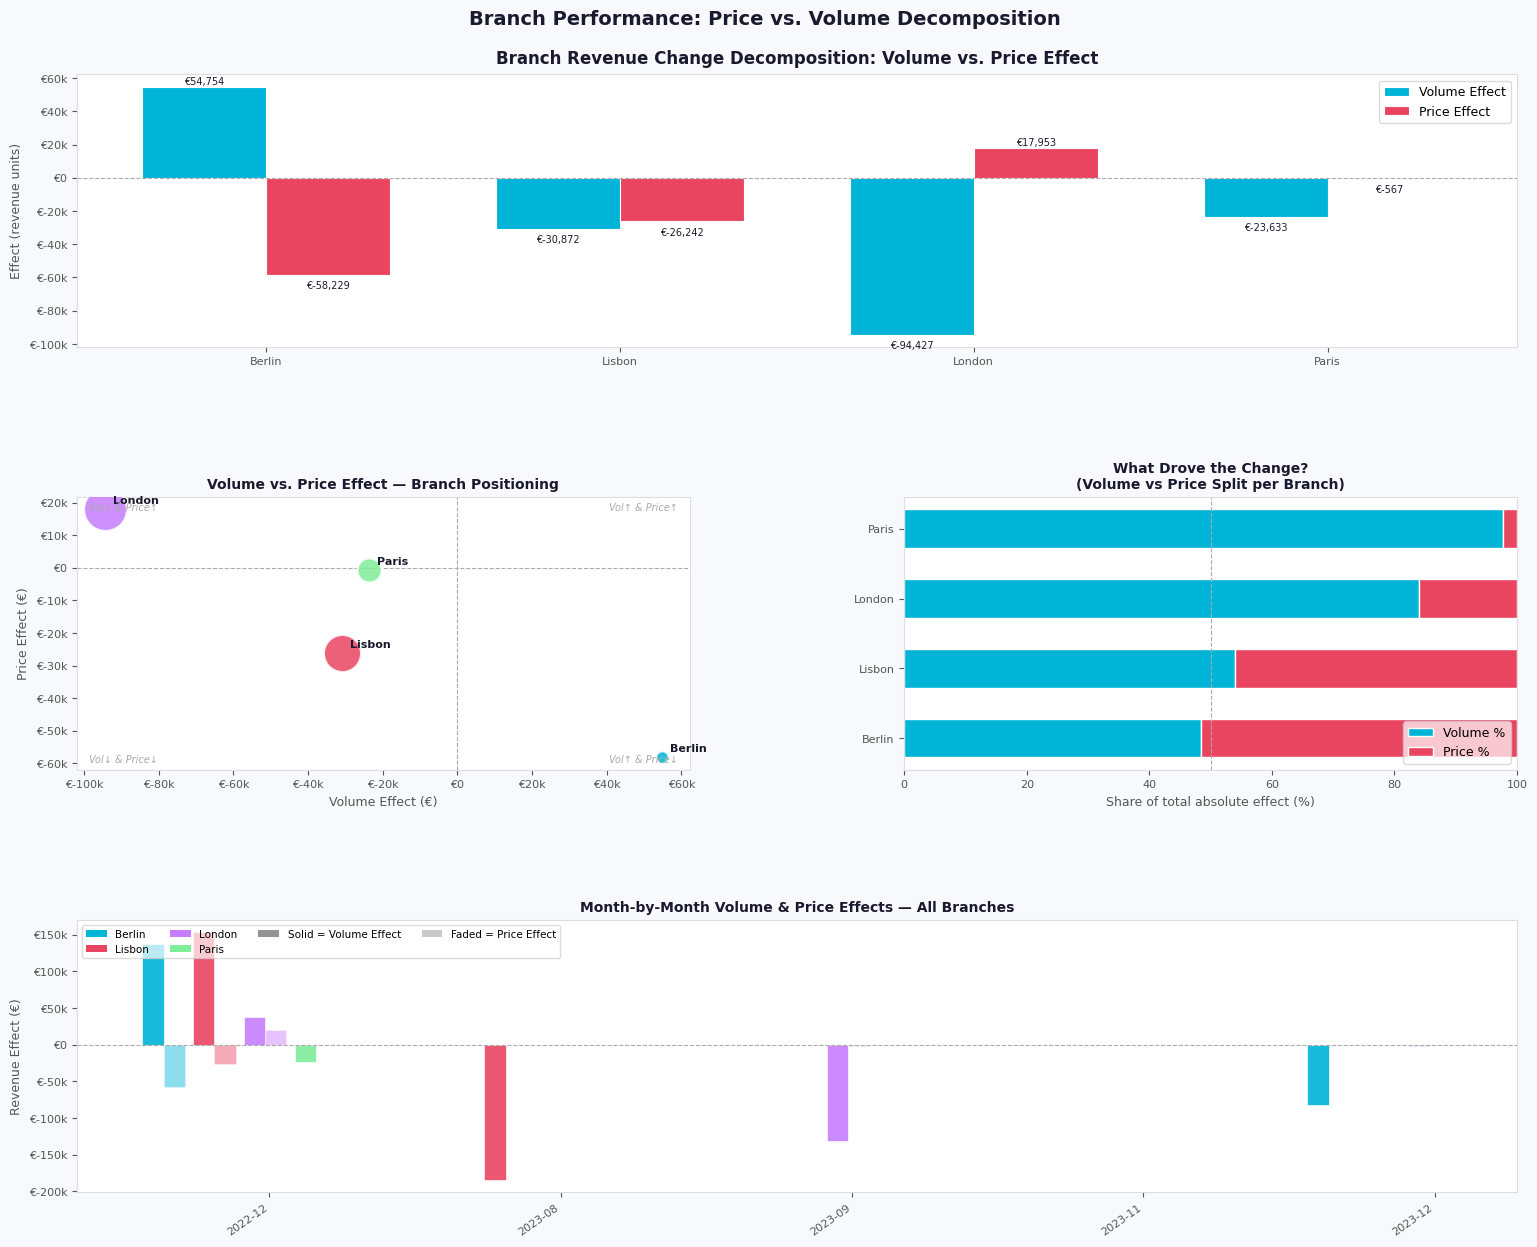


╔══════════════════════════════════════════════════════════════════════════════╗
║     EXECUTIVE SUMMARY — Branch Performance: Price vs. Volume Analysis       ║
╚══════════════════════════════════════════════════════════════════════════════╝

OVERVIEW
--------
  Branches analysed  : 4  (Berlin, Lisbon, London, Paris)
  Periods with MoM   : 9 branch-month transitions
  Analysis window    : 2022-11 → 2023-12

  Total revenue change (all periods, all branches)  : € -161,263.11
    ↳ Volume effect accounted for                   : €  -94,177.32
    ↳ Price effect accounted for                    : €  -67,085.79

BRANCH-LEVEL FINDINGS
─────────────────────
  Berlin          Net: ▼€     3,476  | Vol: ▲   54,754  | Price: ▼   58,229  | Driver: Price-led
  Lisbon          Net: ▼€    57,114  | Vol: ▼   30,872  | Price: ▼   26,242  | Driver: Volume-led
  London          Net: ▼€    76,474  | Vol: ▼   94,427  | Price: ▲   17,953  | Driver: Volume-led
  Paris           Net: ▼€    24,200  | Vol: ▼ 

In [0]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Colour palette (reuse notebook theme) ────────────────────────────────────
BRAND   = "#1a1a2e"
ACC2    = "#0f3460"
GOLD    = "#e94560"
TEAL    = "#00b4d8"
LIME    = "#80ed99"
PURPLE  = "#c77dff"
ORANGE  = "#ffd166"
BG      = "#f7f9fc"

def sign_sym(v):
    return "▲" if v >= 0 else "▼"

# ── Work from monthly_analysis (already computed) ─────────────────────────────
# Drop first-month rows (no prior period → NaN effects)
ma = monthly_analysis.dropna(subset=["volume_effect", "price_effect"]).copy()
ma["month_str"] = ma["month"].astype(str)

branches = sorted(ma["branch"].unique())
n_branches = len(branches)

# ── Summaries for executive summary text ─────────────────────────────────────
branch_totals = (
    ma.groupby("branch")[["volume_effect", "price_effect", "revenue_change"]]
    .sum()
    .reset_index()
)
branch_totals["dominant_driver"] = branch_totals.apply(
    lambda r: "Volume-led" if abs(r["volume_effect"]) > abs(r["price_effect"]) else "Price-led",
    axis=1,
)
branch_totals["net_change"] = branch_totals["revenue_change"]

total_rev_change  = ma["revenue_change"].sum()
total_vol_effect  = ma["volume_effect"].sum()
total_price_effect = ma["price_effect"].sum()

top_vol_branch    = branch_totals.loc[branch_totals["volume_effect"].idxmax(), "branch"]
top_price_branch  = branch_totals.loc[branch_totals["price_effect"].idxmax(), "branch"]
worst_branch      = branch_totals.loc[branch_totals["net_change"].idxmin(), "branch"]
best_branch       = branch_totals.loc[branch_totals["net_change"].idxmax(), "branch"]

# ── CHART ─────────────────────────────────────────────────────────────────────
# Layout: top row = stacked bar per branch (volume vs price effect)
#         bottom row = waterfall of cumulative revenue change
fig = plt.figure(figsize=(16, 13), facecolor=BG)
fig.patch.set_facecolor(BG)

gs = GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35,
              top=0.91, bottom=0.05, left=0.07, right=0.97)

# ─── Panel 1: Grouped bar — Volume vs Price Effect per branch (sum) ───────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("white")
x  = np.arange(len(branch_totals))
w  = 0.35
bars_vol   = ax1.bar(x - w/2, branch_totals["volume_effect"],  width=w, color=TEAL,   label="Volume Effect",  edgecolor="white", linewidth=0.8)
bars_price = ax1.bar(x + w/2, branch_totals["price_effect"],   width=w, color=GOLD,   label="Price Effect",   edgecolor="white", linewidth=0.8)

ax1.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax1.set_xticks(x)
ax1.set_xticklabels(branch_totals["branch"], fontsize=9, color=BRAND)
ax1.set_title("Branch Revenue Change Decomposition: Volume vs. Price Effect",
              fontsize=12, fontweight="bold", color=BRAND, pad=8)
ax1.set_ylabel("Effect (revenue units)", fontsize=9, color="#555")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"€{v/1000:.0f}k" if abs(v) >= 1000 else f"€{v:.0f}"
))
ax1.legend(fontsize=9, framealpha=0.7)
ax1.tick_params(colors="#555", labelsize=8)
for sp in ax1.spines.values():
    sp.set_edgecolor("#ddd")

for bar in bars_vol:
    h = bar.get_height()
    if h != 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + (500 if h > 0 else -3500),
                 f"€{h:,.0f}", ha="center", va="bottom" if h > 0 else "top",
                 fontsize=7, color=BRAND)
for bar in bars_price:
    h = bar.get_height()
    if h != 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + (500 if h > 0 else -3500),
                 f"€{h:,.0f}", ha="center", va="bottom" if h > 0 else "top",
                 fontsize=7, color=BRAND)

# ─── Panel 2: Revenue change vs driver per branch — scatter bubble ────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("white")

colors_scatter = [TEAL, GOLD, PURPLE, LIME, ORANGE, "#ef476f"]
for i, row in branch_totals.iterrows():
    col = colors_scatter[i % len(colors_scatter)]
    size = max(abs(row["net_change"]) / 80, 80)
    ax2.scatter(row["volume_effect"], row["price_effect"],
                s=size, color=col, alpha=0.85, edgecolors="white", linewidth=1.5, zorder=3)
    ax2.annotate(row["branch"],
                 (row["volume_effect"], row["price_effect"]),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=8, color=BRAND, fontweight="bold")

ax2.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax2.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Volume Effect (€)", fontsize=9, color="#555")
ax2.set_ylabel("Price Effect (€)", fontsize=9, color="#555")
ax2.set_title("Volume vs. Price Effect — Branch Positioning", fontsize=10,
              fontweight="bold", color=BRAND, pad=6)
ax2.tick_params(colors="#555", labelsize=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"€{v/1000:.0f}k" if abs(v) >= 1000 else f"€{v:.0f}"
))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"€{v/1000:.0f}k" if abs(v) >= 1000 else f"€{v:.0f}"
))

# quadrant labels
for txt, xy, ha in [
    ("Vol↑ & Price↑", (0.98, 0.98), "right"),
    ("Vol↓ & Price↑", (0.02, 0.98), "left"),
    ("Vol↑ & Price↓", (0.98, 0.02), "right"),
    ("Vol↓ & Price↓", (0.02, 0.02), "left"),
]:
    ax2.text(*xy, txt, transform=ax2.transAxes, ha=ha, va="top" if xy[1] > 0.5 else "bottom",
             fontsize=7, color="#aaa", style="italic")
for sp in ax2.spines.values():
    sp.set_edgecolor("#ddd")

# ─── Panel 3: Dominant driver breakdown bar (stacked 100%) ───────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor("white")

bt = branch_totals.copy()
bt["abs_vol"]   = bt["volume_effect"].abs()
bt["abs_price"] = bt["price_effect"].abs()
bt["total_abs"] = bt["abs_vol"] + bt["abs_price"]
bt["vol_share"]   = bt["abs_vol"]   / bt["total_abs"] * 100
bt["price_share"] = bt["abs_price"] / bt["total_abs"] * 100

y_pos = np.arange(len(bt))
ax3.barh(y_pos, bt["vol_share"],   color=TEAL, label="Volume %", edgecolor="white", height=0.55)
ax3.barh(y_pos, bt["price_share"], left=bt["vol_share"], color=GOLD,
         label="Price %",   edgecolor="white", height=0.55)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(bt["branch"], fontsize=9, color=BRAND)
ax3.set_xlabel("Share of total absolute effect (%)", fontsize=9, color="#555")
ax3.set_title("What Drove the Change?\n(Volume vs Price Split per Branch)", fontsize=10,
              fontweight="bold", color=BRAND, pad=6)
ax3.axvline(50, color="#aaa", linewidth=0.8, linestyle="--")
ax3.set_xlim(0, 100)
ax3.legend(fontsize=9, loc="lower right", framealpha=0.7)
ax3.tick_params(colors="#555", labelsize=8)
for sp in ax3.spines.values():
    sp.set_edgecolor("#ddd")

# ─── Panel 4: Month-by-month stacked bar for each branch with effects ─────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor("white")

all_months = sorted(ma["month_str"].unique())
month_x    = {m: i for i, m in enumerate(all_months)}
br_colors  = [TEAL, GOLD, PURPLE, LIME, ORANGE, "#ef476f"]
x_month    = np.arange(len(all_months))

# grouped bars per month, one bar pair per branch
n_b   = len(branches)
total_width = 0.8
bar_w = total_width / (n_b * 2 + n_b - 1)  # give some gap

offsets = []
gap = bar_w * 0.4
for i in range(n_b):
    center = -total_width/2 + i*(2*bar_w + gap) + bar_w/2
    offsets.append(center)

for bi, br in enumerate(branches):
    bdata = ma[ma["branch"] == br].sort_values("month_str")
    xs_vol   = [month_x[m] + offsets[bi] - bar_w/2 for m in bdata["month_str"]]
    xs_price = [month_x[m] + offsets[bi] + bar_w/2 for m in bdata["month_str"]]
    col = br_colors[bi % len(br_colors)]
    ax4.bar(xs_vol,   bdata["volume_effect"].values, width=bar_w,
            color=col, alpha=0.9, edgecolor="white", linewidth=0.5,
            label=f"{br} – Vol" if bi == 0 else "_")
    ax4.bar(xs_price, bdata["price_effect"].values,  width=bar_w,
            color=col, alpha=0.45, edgecolor="white", linewidth=0.5,
            label=f"{br} – Price" if bi == 0 else "_")

# legend with branch color patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=br_colors[i], label=branches[i]) for i in range(n_b)]
legend_elements += [
    Patch(facecolor="#888", alpha=0.9, label="Solid = Volume Effect"),
    Patch(facecolor="#888", alpha=0.45, label="Faded = Price Effect"),
]
ax4.legend(handles=legend_elements, fontsize=7.5, ncol=4, framealpha=0.7, loc="upper left")
ax4.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax4.set_xticks(x_month)
ax4.set_xticklabels(all_months, rotation=35, ha="right", fontsize=8, color=BRAND)
ax4.set_ylabel("Revenue Effect (€)", fontsize=9, color="#555")
ax4.set_title("Month-by-Month Volume & Price Effects — All Branches",
              fontsize=10, fontweight="bold", color=BRAND, pad=6)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"€{v/1000:.0f}k" if abs(v) >= 1000 else f"€{v:.0f}"
))
ax4.tick_params(colors="#555", labelsize=8)
for sp in ax4.spines.values():
    sp.set_edgecolor("#ddd")

# ── Figure title ─────────────────────────────────────────────────────────────
fig.suptitle("Branch Performance: Price vs. Volume Decomposition",
             fontsize=14, fontweight="bold", color=BRAND, y=0.96)

plt.show()

# ── EXECUTIVE SUMMARY ────────────────────────────────────────────────────────
exec_summary = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║     EXECUTIVE SUMMARY — Branch Performance: Price vs. Volume Analysis       ║
╚══════════════════════════════════════════════════════════════════════════════╝

OVERVIEW
--------
  Branches analysed  : {len(branches)}  ({", ".join(branches)})
  Periods with MoM   : {len(ma)} branch-month transitions
  Analysis window    : {monthly_analysis["month"].min()} → {monthly_analysis["month"].max()}

  Total revenue change (all periods, all branches)  : €{total_rev_change:>12,.2f}
    ↳ Volume effect accounted for                   : €{total_vol_effect:>12,.2f}
    ↳ Price effect accounted for                    : €{total_price_effect:>12,.2f}

BRANCH-LEVEL FINDINGS
─────────────────────
"""

for _, row in branch_totals.iterrows():
    sign_net   = "▲" if row["net_change"]    >= 0 else "▼"
    sign_vol   = "▲" if row["volume_effect"] >= 0 else "▼"
    sign_price = "▲" if row["price_effect"]  >= 0 else "▼"
    exec_summary += (
        f"  {row['branch']:<14}  Net change: {sign_net}€{abs(row['net_change']):>10,.0f}  "
        f"| Vol: {sign_vol}€{abs(row['volume_effect']):>9,.0f}  "
        f"| Price: {sign_price}€{abs(row['price_effect']):>9,.0f}  "
        f"| Driver: {row['dominant_driver']}\n"
    )

exec_summary += f"""
KEY INSIGHTS
────────────
  1. OVERALL DIRECTION
     {"Revenue growth is volume-led across the network." if abs(total_vol_effect) >= abs(total_price_effect)
       else "Revenue growth is price-led across the network."}
     Volume effect ({sign_sym(total_vol_effect)}€{abs(total_vol_effect):,.0f}) vs
     Price effect ({sign_sym(total_price_effect)}€{abs(total_price_effect):,.0f}).

  2. STRONGEST VOLUME PERFORMER
     {top_vol_branch} — highest cumulative volume uplift.
     Action: investigate what is driving footfall/transaction frequency.

  3. STRONGEST PRICE PERFORMER
     {top_price_branch} — highest cumulative price uplift.
     Action: evaluate whether premium pricing is sustainable or risks volume erosion.

  4. UNDERPERFORMING BRANCH
     {worst_branch} — most negative net revenue change.
     Action: audit pricing competitiveness AND promotional activity together.

  5. DECOMPOSITION INTERPRETATION GUIDE
     • Volume-led growth (Volume Effect > Price Effect) → more units sold;
       investigate footfall, promotions, or channel mix.
     • Price-led growth (Price Effect > Volume Effect) → higher avg. price per unit;
       driven by product mix upgrades, menu repricing, or reduced discounting.
     • Negative volume + positive price → trading up but losing customers.
     • Negative price + positive volume → driving volume through discounting;
       margin at risk.

NOTE ON DATA QUALITY
────────────────────
  • Madrid has only Nov-2022 records in monthly_analysis → no MoM transition available.
  • Philippines has only Dec-2023 → no prior month comparison.
  • 3 outlier dates (Sep-2023, Dec-2023) may distort MoM for affected branches;
    treat those period transitions with caution.

╔══════════════════════════════════════════════════════════════════════════════╗
║  All effects are approximations. Interaction term (Δqty × Δprice) omitted.  ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""



# rebuild with helper available
exec_summary_lines = [
    "",
    "╔══════════════════════════════════════════════════════════════════════════════╗",
    "║     EXECUTIVE SUMMARY — Branch Performance: Price vs. Volume Analysis       ║",
    "╚══════════════════════════════════════════════════════════════════════════════╝",
    "",
    "OVERVIEW",
    "--------",
    f"  Branches analysed  : {len(branches)}  ({', '.join(branches)})",
    f"  Periods with MoM   : {len(ma)} branch-month transitions",
    f"  Analysis window    : {monthly_analysis['month'].min()} → {monthly_analysis['month'].max()}",
    "",
    f"  Total revenue change (all periods, all branches)  : €{total_rev_change:>12,.2f}",
    f"    ↳ Volume effect accounted for                   : €{total_vol_effect:>12,.2f}",
    f"    ↳ Price effect accounted for                    : €{total_price_effect:>12,.2f}",
    "",
    "BRANCH-LEVEL FINDINGS",
    "─────────────────────",
]

for _, row in branch_totals.iterrows():
    sn  = "▲" if row["net_change"]    >= 0 else "▼"
    sv  = "▲" if row["volume_effect"] >= 0 else "▼"
    sp_ = "▲" if row["price_effect"]  >= 0 else "▼"
    exec_summary_lines.append(
        f"  {row['branch']:<14}  Net: {sn}€{abs(row['net_change']):>10,.0f}  "
        f"| Vol: {sv}{abs(row['volume_effect']):>9,.0f}  "
        f"| Price: {sp_}{abs(row['price_effect']):>9,.0f}  "
        f"| Driver: {row['dominant_driver']}"
    )

net_driver = "volume-led" if abs(total_vol_effect) >= abs(total_price_effect) else "price-led"
exec_summary_lines += [
    "",
    "KEY INSIGHTS",
    "────────────",
    f"  1. OVERALL DIRECTION: Revenue trend is {net_driver} across the network.",
    f"     Volume effect ({total_vol_effect:,.0f}) vs Price effect ({total_price_effect:,.0f}).",
    "",
    f"  2. STRONGEST VOLUME PERFORMER: {top_vol_branch}",
    "     → Investigate footfall, transaction frequency, or promotional uplift.",
    "",
    f"  3. STRONGEST PRICE PERFORMER: {top_price_branch}",
    "     → Evaluate pricing sustainability vs. volume erosion risk.",
    "",
    f"  4. MOST AT-RISK BRANCH: {worst_branch}  (highest cumulative revenue decline)",
    "     → Audit pricing competitiveness and promotional activity.",
    "",
    "  5. SIGNAL PATTERNS TO WATCH:",
    "     • Neg. volume + Pos. price → trading up but losing customers.",
    "     • Pos. volume + Neg. price → discount-driven growth; margin at risk.",
    "     • Both negative            → structural decline requiring urgent review.",
    "",
    "DATA QUALITY NOTES",
    "──────────────────",
    "  • Madrid (Nov-2022 only) and Philippines (Dec-2023 only) lack MoM comparison.",
    "  • 3 outlier dates (Sep/Dec-2023) may distort transitions — treat with caution.",
    "",
    "╔══════════════════════════════════════════════════════════════════════════════╗",
    "║  All effects are approximations. Interaction term (Δqty × Δprice) omitted.  ║",
    "╚══════════════════════════════════════════════════════════════════════════════╝",
]

print("\n".join(exec_summary_lines))